# Preliminaries

## Load data

In [2]:
# Setup
import yaml
from src.general_analysis.engine import AnalysisEnvironment
from src.barter.regression_models import create_regression_runner
from src.utils import interactive_regression_results_selector

import pandas as pd
import numpy as np
import statsmodels.api as sm

In [3]:
env = AnalysisEnvironment(active_analysis='barter_deals', sandbox_mode=False)

# Load everything
final_df, og_df = env.load_data()
pm, prompt_map = env.load_prompts()

Loading files for analysis Barter Deals Analysis
🐢 Running full processing pipeline...
Results dir: C:\Users\Wouter Barter\Documents\AI_thesis\results\BARTER_DEALS
input_data_path: C:\Users\Wouter Barter\Documents\AI_thesis\data\processed\BARTER_DEALS_MODEL_READY.parquet
Loading evaluations...
Filtered to 12 folders based on allowed_prompt_ids.
⚡ Fast-loading compiled folder: dataset-barter_deals_model-google-gemma-4-E2B-it_prompt-1e1ff82a28e2_prefix-rating
⚡ Fast-loading compiled folder: dataset-barter_deals_model-google-gemma-4-E2B-it_prompt-38c4714f0e3a_prefix-rating
⚡ Fast-loading compiled folder: dataset-barter_deals_model-google-gemma-4-E2B-it_prompt-dbadc59142e9_prefix-rating
⚡ Fast-loading compiled folder: dataset-barter_deals_model-meta-llama-Llama-3.2-3B-Instruct_prompt-1e1ff82a28e2_prefix-rating
⚡ Fast-loading compiled folder: dataset-barter_deals_model-meta-llama-Llama-3.2-3B-Instruct_prompt-38c4714f0e3a_prefix-rating
⚡ Fast-loading compiled folder: dataset-barter_deals_mod

KeyboardInterrupt: 

## Pre-processing

#### Readable Prompt IDs

In [ ]:

prompt_name_mapping = {
    'dbadc59142e9': 'Holistic Naive (1D)',
    '38c4714f0e3a': 'Holistic Informed (3D)',
    '1e1ff82a28e2': 'Formative (10D)',
    # 'd652b4ec75ca': 'Formative New (10D)',
    # 'a01b656496ce': 'Holistic Informed New (3D)',
    # '3ac747c5c39b': 'Holistic Naive (1D)'
    # 'f162d59256cc': 'Formative OLD (10D)'
}

# Clean up the model names to be less cluttered (Optional, but looks much better in legends)
model_name_mapping = {
    'Qwen/Qwen3.5-4B': 'Qwen 3.5',
    'meta-llama/Llama-3.2-3B-Instruct': 'Llama 3.2',
    'google/gemma-4b-it': 'Gemma 4',
    'Qwen/Qwen3-4B-Instruct-2507': 'Qwen 3'
}

# Apply mappings. .fillna() ensures that if a hash isn't in your dict, it just falls back to showing the raw string/hash.
final_df['prompt_clean'] = final_df['prompt_id'].map(
    prompt_name_mapping).fillna(final_df['prompt_id'])
final_df['model_clean'] = final_df['model_name'].map(
    model_name_mapping).fillna(final_df['model_name'])

final_df['Analysis_Group_General'] = final_df['model_clean'] + ' | ' + \
    final_df['prompt_clean']

final_df['Analysis_Group_Full'] = final_df['model_clean'] + ' | ' + \
    final_df['prompt_clean'] + ' | ' + final_df['dimension_name']

### Balance datasets

In [ ]:
def balance_experimental_df(df, input_id_col='input_id', group_cols=['model_name', 'prompt_id']):
    """
    Balances the dataframe so that every experimental group contains 
    the exact same set of unique input_ids. (Long-format safe)
    """
    print(f"Original rows: {len(df)}")

    # 1. Group by the experimental units and collect the set of input_ids for each
    grouped_ids = df.groupby(group_cols)[input_id_col].apply(set)

    # 2. Find the strict intersection
    common_ids = set.intersection(*grouped_ids.values)

    print(f"Unique input_ids appearing in ALL groups: {len(common_ids)}")

    # 3. Filter the dataframe
    balanced_df = df[df[input_id_col].isin(common_ids)].copy()

    # 4. Final verification (Checking UNIQUE ids, not total rows)
    id_counts = balanced_df.groupby(group_cols)[input_id_col].nunique()
    row_counts = balanced_df.groupby(group_cols).size()

    if id_counts.nunique() == 1:
        print(
            f"✅ Success! All groups now evaluate exactly {id_counts.iloc[0]} unique deals.")
        print("\nRow distribution (Formative prompts will show 3x rows due to sub-dimensions):")
        print(row_counts)
    else:
        print("⚠️ Warning: Balancing failed. Check for duplicate input_ids within groups.")
        print(id_counts)

    return balanced_df, common_ids


# # --- EXECUTION ---
# final_df_balanced, gold_set_ids = balance_experimental_df(final_df)

# og_df_balanced = og_df[og_df['deal_id'].isin(gold_set_ids)].copy()

og_df_balanced = og_df.copy()
final_df_balanced = final_df.copy()

### z-standardize 

We need to z-standardize the ratings, to make the coefficients comparable. We saw the because of the truncated scale we work work (1-7), when using the expected value scores on a high-entropy measurement model, the values are pulled towards the mean (See violin plots comparing gemma and qwen). 

New coefficient interpretation:
- "A 1-standard-deviation increase in the AI's rating results in an X% change in creator applications."

- apply to mean

In [ ]:
import pandas as pd

print("--- 🚀 STANDARDIZING MEASUREMENTS FOR ECONOMETRIC COMPARISON ---")

# 1. Apply the Z-score transformation using groupby and transform
# We use ddof=1 for the sample standard deviation
final_df_balanced['z_mean_rating'] = final_df_balanced.groupby(
    ['model_name', 'prompt_id', 'dimension_name']
)['mean_rating'].transform(lambda x: (x - x.mean()) / x.std(ddof=1))

# 2. Quick Sanity Check
# Let's verify that the means are 0 and standard deviations are 1 for our two main models
sanity_check = final_df_balanced[
    final_df_balanced['model_name'].isin(
        ['Qwen/Qwen3.5-4B', 'google/gemma-4-E2B-it'])
].groupby(['model_name', 'dimension_name'])['z_mean_rating'].agg(['mean', 'std']).round(3).head(10)

print("\nSanity Check: Means should be 0.0, Standard Deviations should be 1.0")
display(sanity_check)

--- 🚀 STANDARDIZING MEASUREMENTS FOR ECONOMETRIC COMPARISON ---

Sanity Check: Means should be 0.0, Standard Deviations should be 1.0


mean  std
model_name      dimension_name                                   
Qwen/Qwen3.5-4B deal_pitch_brand_prestige                0.0  1.0
                deal_pitch_call_to_action_strength      -0.0  1.0
                deal_pitch_creative_restrictiveness      0.0  1.0
                deal_pitch_creator_brand_alignment       0.0  1.0
                deal_pitch_creator_content_fit           0.0  1.0
                deal_pitch_functional_utility            0.0  1.0
                deal_pitch_overall_deal_attractiveness   0.0  1.0
                deal_pitch_overall_pitch_quality        -0.0  1.0
                deal_pitch_overall_reward_value          0.0  1.0
                deal_pitch_overall_task_demand           0.0  1.0

- apply to mode

In [ ]:
import pandas as pd

print("--- 🚀 STANDARDIZING MEASUREMENTS FOR ECONOMETRIC COMPARISON ---")

# 1. Apply the Z-score transformation using groupby and transform
# We use ddof=1 for the sample standard deviation
final_df_balanced['z_mode_rating'] = final_df_balanced.groupby(
    ['model_name', 'prompt_id', 'dimension_name']
)['mode_rating'].transform(lambda x: (x - x.mean()) / x.std(ddof=1))

# 2. Quick Sanity Check
# Let's verify that the means are 0 and standard deviations are 1 for our two main models
sanity_check = final_df_balanced[
    final_df_balanced['model_name'].isin(
        ['Qwen/Qwen3.5-4B', 'google/gemma-4-E2B-it'])
].groupby(['model_name', 'dimension_name'])['z_mode_rating'].agg(['mean', 'std']).round(3).head(10)

print("\nSanity Check: Means should be 0.0, Standard Deviations should be 1.0")
display(sanity_check)

--- 🚀 STANDARDIZING MEASUREMENTS FOR ECONOMETRIC COMPARISON ---

Sanity Check: Means should be 0.0, Standard Deviations should be 1.0


mean  std
model_name      dimension_name                                   
Qwen/Qwen3.5-4B deal_pitch_brand_prestige                0.0  1.0
                deal_pitch_call_to_action_strength       0.0  1.0
                deal_pitch_creative_restrictiveness     -0.0  1.0
                deal_pitch_creator_brand_alignment       0.0  1.0
                deal_pitch_creator_content_fit          -0.0  1.0
                deal_pitch_functional_utility            0.0  1.0
                deal_pitch_overall_deal_attractiveness   0.0  1.0
                deal_pitch_overall_pitch_quality        -0.0  1.0
                deal_pitch_overall_reward_value         -0.0  1.0
                deal_pitch_overall_task_demand           0.0  1.0

### Add col for 'social media category' 

In [ ]:
import numpy as np
import pandas as pd

print("--- 🚀 OPTIMIZED GREPPING (O(N) on Base Deals) ---")

# 1. Perform string concatenation strictly on the unique base dataframe
combined_text = (
    og_df_balanced['deal_title'].fillna('') + ' ' +
    og_df_balanced['deal_text'].fillna('') + ' ' +
    og_df_balanced['creators_requirement'].fillna('')
).str.lower()

# 2. Extract platforms using regex
platforms = {
    'instagram': r'\b(?:instagram|ig|insta)\b',
    'tiktok': r'\btiktok\b',
    'youtube': r'\b(?:youtube|yt)\b',
    'facebook': r'\b(?:facebook|fb)\b'
}

# We can store these temporarily directly in og_df_balanced
for plat, regex_pattern in platforms.items():
    og_df_balanced[f'req_{plat}'] = combined_text.str.contains(
        regex_pattern, regex=True).astype(int)

# 3. Calculate platform count per deal
og_df_balanced['platform_count'] = og_df_balanced[[
    f'req_{p}' for p in platforms.keys()]].sum(axis=1)
print("--- 🚀 REGROUPING PLATFORMS FOR STATISTICAL STABILITY ---")

# We update the conditions to fold YouTube, Facebook, and Omnichannel into one bucket
conditions = [
    (og_df_balanced['req_instagram'] == 1) & (
        og_df_balanced['platform_count'] == 1),
    (og_df_balanced['req_tiktok'] == 1) & (
        og_df_balanced['platform_count'] == 1),
    (og_df_balanced['req_instagram'] == 1) & (
        og_df_balanced['req_tiktok'] == 1) & (og_df_balanced['platform_count'] == 2),
    # Keep Unspecified separate, as it means "blank"
    (og_df_balanced['platform_count'] == 0)
]

choices = [
    'Instagram_Only',
    'TikTok_Only',
    'IG_and_TikTok',
    'Unspecified'
]

# Anything that doesn't fit the simple IG/TikTok molds (e.g., YouTube, 3+ platforms, FB)
# gets grouped into a catch-all high-complexity bucket.
og_df_balanced['platform_strategy'] = np.select(
    conditions,
    choices,
    default='High_Friction_Deliverable'
)

print("\nUpdated Distribution in Base Data:")
print(og_df_balanced['platform_strategy'].value_counts())


# 5. Broadcast (Merge) back to the long analysis dataframe
print("\n--- 🔗 MERGING BACK TO FINAL DATAFRAME ---")

# We only bring over the column we need to avoid bloating final_df_balanced
merge_cols = ['deal_id', 'platform_strategy']

final_df_balanced = final_df_balanced.merge(
    og_df_balanced[merge_cols],
    on='deal_id',
    how='left'
)

# Optional cleanup: drop the redundant 'deal_id' column if it was copied over during the merge
# if 'deal_id' in final_df_balanced.columns and 'deal_id' != 'input_id':
#     final_df_balanced = final_df_balanced.drop(columns=['deal_id'])

print("Merge complete! 'platform_strategy' is now ready for regression.")

--- 🚀 OPTIMIZED GREPPING (O(N) on Base Deals) ---
--- 🚀 REGROUPING PLATFORMS FOR STATISTICAL STABILITY ---

Updated Distribution in Base Data:
platform_strategy
IG_and_TikTok                1067
Unspecified                   864
TikTok_Only                   479
Instagram_Only                450
High_Friction_Deliverable     279
Name: count, dtype: int64

--- 🔗 MERGING BACK TO FINAL DATAFRAME ---
Merge complete! 'platform_strategy' is now ready for regression.


# Regression models

## Basic

### Mean rating

In [ ]:
CONTENT_TYPE_COL = 'macro_category'

CATEGORICALS = ['market_scope', CONTENT_TYPE_COL,
                'year_month', 'platform_strategy', 'length_bucket']
CONTINUOUS = ['log_competitor_density', 'log_requirements_word_count']
CONTINUOUS = ['competitor_density', 'log_requirements_word_count',
              'log_title_word_count', 'log_text_word_count']

BINARIES = ['strict_follower_requirement']
EXPERIMENTAL_GROUPS = ['model_name', 'prompt_id']
EXPERIMENTAL_GROUPS = ['Analysis_Group_General']

runner = create_regression_runner(
    target_col='apps_after_7_days',  # Log-transformed target
    experimental_groups=EXPERIMENTAL_GROUPS,
    cluster_col='partner_id',
    model_type='negbin'
)

runner.run_baseline_model(
    df=og_df_balanced,
    cat_vars=CATEGORICALS,
    bin_vars=BINARIES,
    num_vars=CONTINUOUS,
    label="baseline"
)


# predictor_name = 'mean_rating'
predictor_name = 'z_mean_rating'

runner.run_regression(df=final_df_balanced,
                      cat_vars=CATEGORICALS,
                      bin_vars=BINARIES,
                      num_vars=CONTINUOUS,
                      predictor_name=predictor_name)

interactive_regression_results_selector(runner.results)

NameError: name 'create_regression_runner' is not defined

### Mode rating

In [ ]:
CONTENT_TYPE_COL = 'macro_category'

CATEGORICALS = ['market_scope', CONTENT_TYPE_COL,
                'year_month', 'platform_strategy']
CONTINUOUS = ['log_competitor_density', 'log_requirements_word_count']
CONTINUOUS = ['competitor_density', 'log_requirements_word_count',
              'log_title_word_count', 'log_text_word_count']

BINARIES = ['strict_follower_requirement']
EXPERIMENTAL_GROUPS = ['model_name', 'prompt_id']
EXPERIMENTAL_GROUPS = ['Analysis_Group_General']


runner = create_regression_runner(
    target_col='apps_after_7_days',  # Log-transformed target
    experimental_groups=EXPERIMENTAL_GROUPS,
    cluster_col='partner_id',
    model_type='negbin'
)

runner.run_baseline_model(
    df=og_df_balanced,
    cat_vars=CATEGORICALS,
    bin_vars=BINARIES,
    num_vars=CONTINUOUS,
    label="baseline"
)


# predictor_name = 'mean_rating'
predictor_name = 'z_mode_rating'

runner.run_regression(df=final_df_balanced,
                      cat_vars=CATEGORICALS,
                      bin_vars=BINARIES,
                      num_vars=CONTINUOUS,
                      predictor_name=predictor_name)

interactive_regression_results_selector(runner.results)

Dropdown(description='Select option:', index=11, layout=Layout(width='400px'), options=('baseline', "('Llama 3…

<class 'statsmodels.iolib.summary.Summary'>
"""
                     NegativeBinomial Regression Results                      
==============================================================================
Dep. Variable:      apps_after_7_days   No. Observations:                 3138
Model:               NegativeBinomial   Df Residuals:                     3095
Method:                           MLE   Df Model:                           42
Date:                Wed, 22 Apr 2026   Pseudo R-squ.:                 0.06109
Time:                        17:05:58   Log-Likelihood:                -11090.
converged:                       True   LL-Null:                       -11812.
Covariance Type:              cluster   LLR p-value:                2.423e-275
========================================================================================================
                                           coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------------------------------
const                                    3.2361      0.303     10.697      0.000       2.643       3.830
deal_pitch_brand_prestige                0.0348      0.031      1.141      0.254      -0.025       0.095
deal_pitch_perceived_economic_value      0.0867      0.031      2.826      0.005       0.026       0.147
deal_pitch_creator_content_fit           0.0130      0.032      0.413      0.680      -0.049       0.075
deal_pitch_functional_utility           -0.0306      0.028     -1.080      0.280      -0.086       0.025
deal_pitch_product_universality          0.2268      0.029      7.889      0.000       0.170       0.283
deal_pitch_workload_volume               0.0199      0.030      0.671      0.503      -0.038       0.078
deal_pitch_creative_restrictiveness      0.0186      0.029      0.644      0.519      -0.038       0.075
deal_pitch_call_to_action_strength       0.0835      0.033      2.555      0.011       0.019       0.148
deal_pitch_promotional_hype_level        0.0036      0.030      0.118      0.906      -0.056       0.063
deal_pitch_proposition_clarity           0.0089      0.037      0.242      0.809      -0.063       0.081
strict_follower_requirement             -0.2035      0.056     -3.630      0.000      -0.314      -0.094
competitor_density                      -0.0410      0.007     -6.037      0.000      -0.054      -0.028
log_requirements_word_count             -0.1297      0.037     -3.530      0.000      -0.202      -0.058
log_title_word_count                     0.0254      0.082      0.310      0.757      -0.135       0.186
log_text_word_count                     -0.0993      0.040     -2.494      0.013      -0.177      -0.021
market_scope_Tier2_NLD_only             -0.3270      0.064     -5.149      0.000      -0.452      -0.202
market_scope_Tier3_BEL_Only             -1.1944      0.155     -7.708      0.000      -1.498      -0.890
market_scope_Tier4_Germany              -1.6722      0.075    -22.378      0.000      -1.819      -1.526
macro_category_Beauty                    0.6006      0.177      3.398      0.001       0.254       0.947
macro_category_Digital Entertainment    -0.1184      0.188     -0.629      0.530      -0.488       0.251
macro_category_Dining & Hospitality      0.1318      0.180      0.733      0.464      -0.221       0.484
macro_category_Family & Parenting        0.0310      0.208      0.149      0.882      -0.378       0.440
macro_category_Fashion                   0.4814      0.186      2.585      0.010       0.116       0.847
macro_category_Home Cooking & CPG        0.3002      0.173      1.740      0.082      -0.038       0.639
macro_category_In-Person Experiences    -0.3654      0.216     -1.695      0.090      -0.788       0.058
macro_category_Lifestyle & Home          0.5781      0.182      3.169      0.002       0.220       0.936
macro_category_Tech & Niche             -0.2436      0.234     -1.042      0.297      -0.70

# Analysis

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import ipywidgets as widgets
from IPython.display import display, clear_output

In [ ]:
# 1. PRE-PROCESS DATA ONCE (Massive speedup)
# Create a copy so we don't mess with your main dataframe
plot_df = final_df_balanced.copy()

### Nr of local maxima

In [ ]:
import numpy as np


def compute_multimodality(logits_matrix):
    """
    Computes the number of local maxima for an (N, 7) array of probabilities or logits.

    Parameters:
    logits_matrix (np.ndarray): A 2D array where columns are strictly ordered [1, 2, 3, 4, 5, 6, 7]

    Returns:
    np.ndarray: A 1D array of length N containing the integer count of peaks per row.
    """
    # 1. Pad the left and right edges with -infinity
    # Shape goes from (N, 7) to (N, 9)
    padded = np.pad(
        logits_matrix,
        pad_width=((0, 0), (1, 1)),
        mode='constant',
        constant_values=-np.inf
    )

    # 2. A point is a local maximum if it is strictly greater than BOTH neighbors
    # We compare the original 7 columns against the shifted padding
    is_greater_than_left = padded[:, 1:-1] > padded[:, :-2]
    is_greater_than_right = padded[:, 1:-1] > padded[:, 2:]

    # 3. Find where both conditions are True
    is_peak = is_greater_than_left & is_greater_than_right

    # 4. Count the peaks per row
    num_peaks_per_row = is_peak.sum(axis=1)

    return num_peaks_per_row

In [ ]:

# 1. Flatten the entire matrix at once (Way faster than doing it per-group)
logits_matrix = np.array(final_df['sorted_logits'].tolist())
if logits_matrix.ndim == 3:
    logits_matrix = logits_matrix.squeeze(axis=1)

# 2. Compute the peaks and create a binary flag (True/False acts as 1/0)
final_df['peak_count'] = compute_multimodality(logits_matrix)
final_df['is_multimodal'] = final_df['peak_count'] > 1

# 3. The Clean GroupBy
multimodal_stats = (
    final_df.groupby('Analysis_Group_General')['is_multimodal']
    .agg(
        Failure_Rate='mean',   # The mean of True/False gives the exact percentage
        Std_Dev='std',         # Standard deviation of the binary outcome
        Total_Evaluations='count'  # Always good to see sample size per group
    )
    .sort_values('Failure_Rate', ascending=False)  # Sort worst to best
)

# 4. Make it pretty for the notebook output
styled_stats = multimodal_stats.style.format({
    'Failure_Rate': '{:.2%}'.format,  # Formats 0.73 as 73.00%
    'Std_Dev': '{:.4f}'.format,
    'Total_Evaluations': '{:,}'.format
}).background_gradient(subset=['Failure_Rate'], cmap='Reds')

styled_stats

,Failure_Rate,Std_Dev,Total_Evaluations
Analysis_Group_General,,,
Llama 3.2 | Formative New (10D),7.93%,0.2703,"31,380"
Llama 3.2 | Holistic Naive (1D),5.75%,0.2329,"6,276"
Llama 3.2 | Formative (10D),4.65%,0.2106,"31,380"
Qwen 3.5 | aaed425bb6d8,4.35%,0.2039,"31,380"
Qwen 3.5 | Formative New (10D),3.36%,0.1801,"31,380"
Qwen 3.5 | Holistic Informed New (3D),2.95%,0.1693,"9,414"
Qwen 3.5 | Formative (10D),1.94%,0.1380,"31,380"
Qwen 3.5 | Holistic Naive (1D),1.23%,0.1101,"6,276"
Llama 3.2 | Holistic Informed New (3D),0.71%,0.0841,"9,414"


In [ ]:
# multimodal_stats.to_csv('multimodal_stats.csv')

In [ ]:
logits_matrix = np.array(final_df['sorted_logits'].tolist())
logits_matrix = logits_matrix.squeeze(axis=1)

In [ ]:
final_df.groupby(['Analysis_Group_General'])['sorted_logits'].apply(lambda x: (
    (compute_multimodality(np.array(x.tolist()).squeeze(axis=1))) > 1).mean())

Analysis_Group_General
Llama 3.2 | Formative (10D)               0.046495
Llama 3.2 | Formative New (10D)           0.079350
Llama 3.2 | Holistic Informed (3D)        0.002124
Llama 3.2 | Holistic Informed New (3D)    0.007117
Llama 3.2 | Holistic Naive (1D)           0.057521
Qwen 3.5 | Formative (10D)                0.019407
Qwen 3.5 | Formative New (10D)            0.033556
Qwen 3.5 | Holistic Informed (3D)         0.003612
Qwen 3.5 | Holistic Informed New (3D)     0.029530
Qwen 3.5 | Holistic Naive (1D)            0.012269
Qwen 3.5 | aaed425bb6d8                   0.043467
Name: sorted_logits, dtype: float64

In [ ]:
final_df.groupby(['Analysis_Group_Full'])['sorted_logits'].apply(lambda x: (
    (compute_multimodality(np.array(x.tolist()).squeeze(axis=1))) > 1).mean())

Analysis_Group_Full
Llama 3.2 | Formative (10D) | deal_pitch_brand_prestige              0.020076
Llama 3.2 | Formative (10D) | deal_pitch_call_to_action_strength     0.018164
Llama 3.2 | Formative (10D) | deal_pitch_creative_restrictiveness    0.004143
Llama 3.2 | Formative (10D) | deal_pitch_creator_brand_alignment     0.260038
Llama 3.2 | Formative (10D) | deal_pitch_functional_utility          0.023263
                                                                       ...   
Qwen 3.5 | aaed425bb6d8 | deal_pitch_perceived_economic_value        0.004143
Qwen 3.5 | aaed425bb6d8 | deal_pitch_product_universality            0.008604
Qwen 3.5 | aaed425bb6d8 | deal_pitch_promotional_hype_level          0.009879
Qwen 3.5 | aaed425bb6d8 | deal_pitch_proposition_clarity             0.046208
Qwen 3.5 | aaed425bb6d8 | deal_pitch_workload_volume                 0.033142
Name: sorted_logits, Length: 64, dtype: float64

### Density plots (EV, Entropy)

--- 🚀 INTERACTIVE CROSS-MODEL DASHBOARD ---


SelectMultiple(description='Groups:', index=(0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10), layout=Layout(width='80%'), op…

Button(button_style='primary', description='Render Plots', icon='play', style=ButtonStyle())

Output()

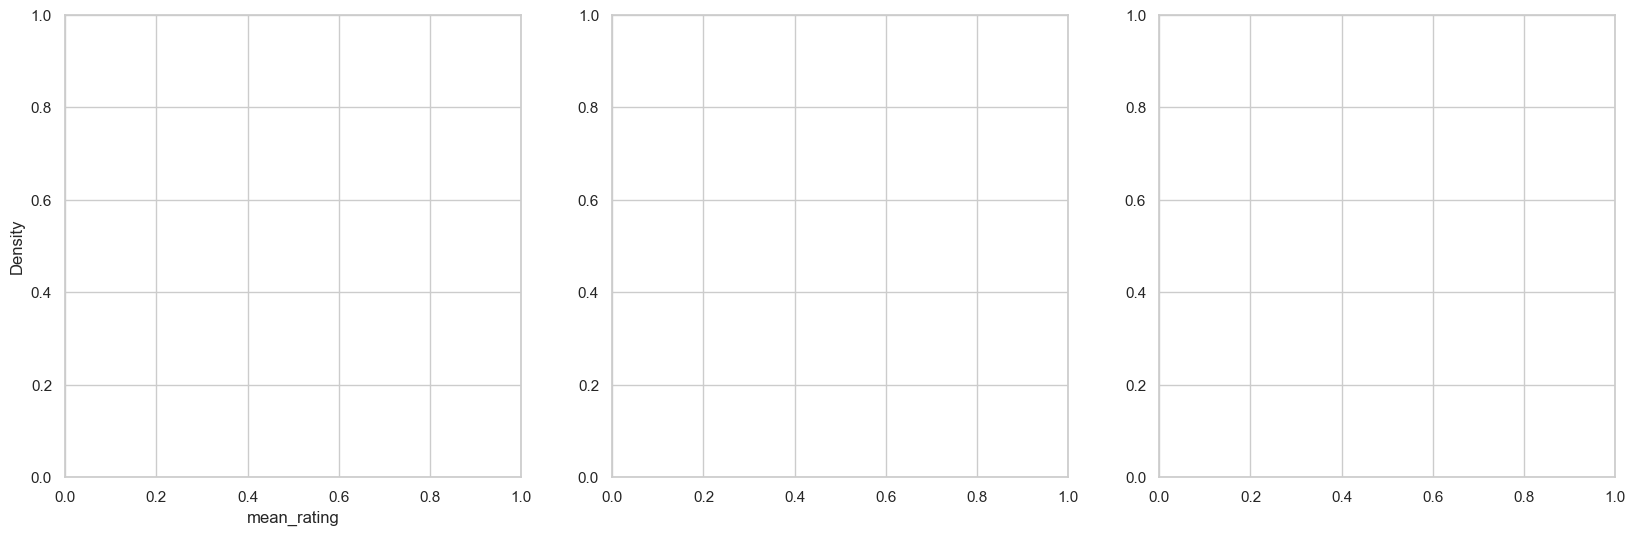

In [ ]:
print("--- 🚀 INTERACTIVE CROSS-MODEL DASHBOARD ---")

# Vectorized math for the deviation metric
plot_df['dev_from_mode'] = (
    plot_df['mean_rating'] - plot_df['mode_rating']).abs()

# Detect all unique groups automatically
all_groups = sorted(plot_df['Analysis_Group_General'].unique().tolist())

# Create a stable, dynamic color palette so colors stay consistent across selections
colors = sns.color_palette("husl", n_colors=len(all_groups))
stable_palette = dict(zip(all_groups, colors))

# 2. CREATE THE INTERACTIVE WIDGETS
group_selector = widgets.SelectMultiple(
    options=all_groups,
    value=all_groups,  # Default selects all of them
    rows=min(10, len(all_groups)),  # Dynamically scale the box size
    description='Groups:',
    layout=widgets.Layout(width='80%')
)

run_button = widgets.Button(
    description='Render Plots',
    button_style='primary',
    icon='play'
)

output_area = widgets.Output()

# 3. DEFINE THE PLOTTING FUNCTION


def render_interactive_plots(b):
    with output_area:
        # Clears the old plot before drawing the new one
        clear_output(wait=True)

        selected_groups = list(group_selector.value)

        if not selected_groups:
            print("⚠️ Please select at least one group from the menu.")
            return

        # Filter the dataframe instantly
        filtered_df = plot_df[plot_df['Analysis_Group_General'].isin(
            selected_groups)]

        # Set up visual style
        sns.set_theme(style="whitegrid")
        fig, axes = plt.subplots(1, 3, figsize=(20, 6))

        # ---------------------------------------------------------
        # PLOT 1: KDE of Mean Ratings
        # ---------------------------------------------------------
        ax = axes[0]
        sns.kdeplot(data=filtered_df, x='mean_rating', hue='Analysis_Group_General',
                    palette=stable_palette, ax=ax, fill=True, alpha=0.3, bw_adjust=0.5, linewidth=2, common_norm=False)
        ax.set_title("1. Distribution of Expected Ratings",
                     fontsize=14, fontweight='bold')
        ax.set_xlabel("Expected Value Rating (1 to 7)")
        ax.set_ylabel("Density")

        # ---------------------------------------------------------
        # PLOT 2: ECDF of Absolute Deviation
        # ---------------------------------------------------------
        ax = axes[1]
        sns.ecdfplot(data=filtered_df, x='dev_from_mode', hue='Analysis_Group_General',
                     palette=stable_palette, ax=ax, lw=2.5)
        ax.set_title("2. Cumulative Deviation from Integer Mode",
                     fontsize=14, fontweight='bold')
        ax.set_xlabel("Absolute Difference: |Mean - Mode|")
        ax.set_ylabel("Cumulative Proportion")

        # ---------------------------------------------------------
        # PLOT 3: Entropy Distributions
        # ---------------------------------------------------------
        ax = axes[2]
        sns.kdeplot(data=filtered_df, x='normalized_entropy', hue='Analysis_Group_General',
                    palette=stable_palette, ax=ax, fill=True, alpha=0.3, linewidth=2, common_norm=False)
        ax.set_title("3. Model Uncertainty (Normalized Entropy)",
                     fontsize=14, fontweight='bold')
        ax.set_xlabel("Entropy (0 = Certainty, 1 = Max Uncertainty)")
        ax.set_ylabel("Density")

        plt.tight_layout()
        plt.show()


# 4. BIND BUTTON AND DISPLAY
run_button.on_click(render_interactive_plots)
display(group_selector, run_button, output_area)

In [ ]:
final_df.groupby('Analysis_Group_Full')['normalized_entropy'].mean()

Analysis_Group_Full
Llama 3.2 | Formative (10D) | deal_pitch_brand_prestige              0.795217
Llama 3.2 | Formative (10D) | deal_pitch_call_to_action_strength     0.667597
Llama 3.2 | Formative (10D) | deal_pitch_creative_restrictiveness    0.673037
Llama 3.2 | Formative (10D) | deal_pitch_creator_brand_alignment     0.731158
Llama 3.2 | Formative (10D) | deal_pitch_functional_utility          0.652734
                                                                       ...   
Qwen 3.5 | aaed425bb6d8 | deal_pitch_perceived_economic_value        0.686626
Qwen 3.5 | aaed425bb6d8 | deal_pitch_product_universality            0.657006
Qwen 3.5 | aaed425bb6d8 | deal_pitch_promotional_hype_level          0.665662
Qwen 3.5 | aaed425bb6d8 | deal_pitch_proposition_clarity             0.673743
Qwen 3.5 | aaed425bb6d8 | deal_pitch_workload_volume                 0.695390
Name: normalized_entropy, Length: 64, dtype: float64

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np
import ipywidgets as widgets
from IPython.display import display, clear_output

print("--- 🚀 GRANULAR INTERACTIVE KDE DASHBOARD ---")

# 1. PRE-PROCESS DATA
plot_df = final_df_balanced.copy()

# prompt_name_mapping = {
#     'dbadc59142e9': 'Holistic Naive (1D)',
#     '38c4714f0e3a': 'Holistic Informed (3D)',
#     '1e1ff82a28e2': 'Formative NEW (10D)',
#     'f162d59256cc': 'Formative OLD (10D)'
# }

# model_name_mapping = {
#     'Qwen/Qwen3-4B-Instruct-2507': 'Qwen 3.5',
#     'meta-llama/Llama-3.2-3B-Instruct': 'Llama 3.2',
#     # 'google/gemma-4b-it': 'Gemma 4'
# }

# plot_df['prompt_clean'] = plot_df['prompt_id'].map(
#     prompt_name_mapping).fillna(plot_df['prompt_id'])
# plot_df['model_clean'] = plot_df['model_name'].map(
#     model_name_mapping).fillna(plot_df['model_name'])

# # ---> NEW: Group by Model, Prompt AND Dimension <---
# plot_df['Analysis_Group'] = plot_df['model_clean'] + ' | ' + \
#     plot_df['prompt_clean'] + ' | ' + plot_df['dimension_name']

# Vectorized math for the deviation metric
plot_df['dev_from_mode'] = (
    plot_df['mean_rating'] - plot_df['mode_rating']).abs()

# Detect all unique groups automatically
all_groups = sorted(plot_df['Analysis_Group_Full'].unique().tolist())

# Create a stable, dynamic color palette so colors stay consistent across selections
colors = sns.color_palette("husl", n_colors=len(all_groups))
stable_palette = dict(zip(all_groups, colors))

# 2. CREATE THE INTERACTIVE WIDGETS
group_selector = widgets.SelectMultiple(
    options=all_groups,
    # Default selects only the first 3 to prevent immediate spaghetti
    value=all_groups[:3],
    rows=15,  # Dynamically scale the box size to handle the large list
    description='Groups:',
    # Make the box wider so the long text fits
    layout=widgets.Layout(width='90%')
)

run_button = widgets.Button(
    description='Render Plots',
    button_style='primary',
    icon='play'
)

output_area = widgets.Output()

# 3. DEFINE THE PLOTTING FUNCTION


def render_interactive_plots(b):
    with output_area:
        # Clears the old plot before drawing the new one
        clear_output(wait=True)

        selected_groups = list(group_selector.value)

        if not selected_groups:
            print("⚠️ Please select at least one group from the menu.")
            return

        # Filter the dataframe instantly
        filtered_df = plot_df[plot_df['Analysis_Group_Full'].isin(
            selected_groups)]

        # Set up visual style
        sns.set_theme(style="whitegrid")
        fig, axes = plt.subplots(1, 3, figsize=(20, 6))

        # ---------------------------------------------------------
        # PLOT 1: KDE of Mean Ratings
        # ---------------------------------------------------------
        ax = axes[0]
        sns.kdeplot(data=filtered_df, x='mean_rating', hue='Analysis_Group_Full',
                    palette=stable_palette, ax=ax, fill=True, alpha=0.3, bw_adjust=0.5, linewidth=2, common_norm=False)
        ax.set_title("1. Distribution of Expected Ratings",
                     fontsize=14, fontweight='bold')
        ax.set_xlabel("Expected Value Rating (1 to 7)")
        ax.set_ylabel("Density")

        # Move legend outside the plot so it doesn't cover the data
        sns.move_legend(ax, "lower center", bbox_to_anchor=(
            0.5, -0.4), ncol=1, title=None, frameon=False)

        # ---------------------------------------------------------
        # PLOT 2: ECDF of Absolute Deviation
        # ---------------------------------------------------------
        ax = axes[1]
        sns.ecdfplot(data=filtered_df, x='dev_from_mode', hue='Analysis_Group_Full',
                     palette=stable_palette, ax=ax, lw=2.5)
        ax.set_title("2. Cumulative Deviation from Integer Mode",
                     fontsize=14, fontweight='bold')
        ax.set_xlabel("Absolute Difference: |Mean - Mode|")
        ax.set_ylabel("Cumulative Proportion")
        axes[1].get_legend().remove()  # Remove redundant legends

        # ---------------------------------------------------------
        # PLOT 3: Entropy Distributions
        # ---------------------------------------------------------
        ax = axes[2]
        sns.kdeplot(data=filtered_df, x='normalized_entropy', hue='Analysis_Group_Full',
                    palette=stable_palette, ax=ax, fill=True, alpha=0.3, linewidth=2, common_norm=False)
        ax.set_title("3. Model Uncertainty (Normalized Entropy)",
                     fontsize=14, fontweight='bold')
        ax.set_xlabel("Entropy (0 = Certainty, 1 = Max Uncertainty)")
        ax.set_ylabel("Density")
        axes[2].get_legend().remove()  # Remove redundant legends

        plt.tight_layout()
        plt.show()


# 4. BIND BUTTON AND DISPLAY
run_button.on_click(render_interactive_plots)
display(group_selector, run_button, output_area)

--- 🚀 GRANULAR INTERACTIVE KDE DASHBOARD ---


SelectMultiple(description='Groups:', index=(0, 1, 2), layout=Layout(width='90%'), options=('Llama 3.2 | Forma…

Button(button_style='primary', description='Render Plots', icon='play', style=ButtonStyle())

Output()

      prompt_id                       dimension_name  expected_std  \
1  1e1ff82a28e2   deal_pitch_call_to_action_strength      0.559846   
5  1e1ff82a28e2  deal_pitch_perceived_economic_value      0.484622   
4  1e1ff82a28e2        deal_pitch_functional_utility      0.456466   
0  1e1ff82a28e2            deal_pitch_brand_prestige      0.439007   
3  1e1ff82a28e2   deal_pitch_creator_brand_alignment      0.408881   
7  1e1ff82a28e2       deal_pitch_proposition_clarity      0.374818   
9  1e1ff82a28e2           deal_pitch_workload_volume      0.335497   
8  1e1ff82a28e2    deal_pitch_rhetorical_objectivity      0.326208   
6  1e1ff82a28e2      deal_pitch_product_universality      0.248286   
2  1e1ff82a28e2  deal_pitch_creative_restrictiveness      0.135535   

   entropy_mean  
1      0.667597  
5      0.670415  
4      0.652734  
0      0.795217  
3      0.731158  
7      0.669678  
9      0.557570  
8      0.739936  
6      0.729461  
2      0.673037  


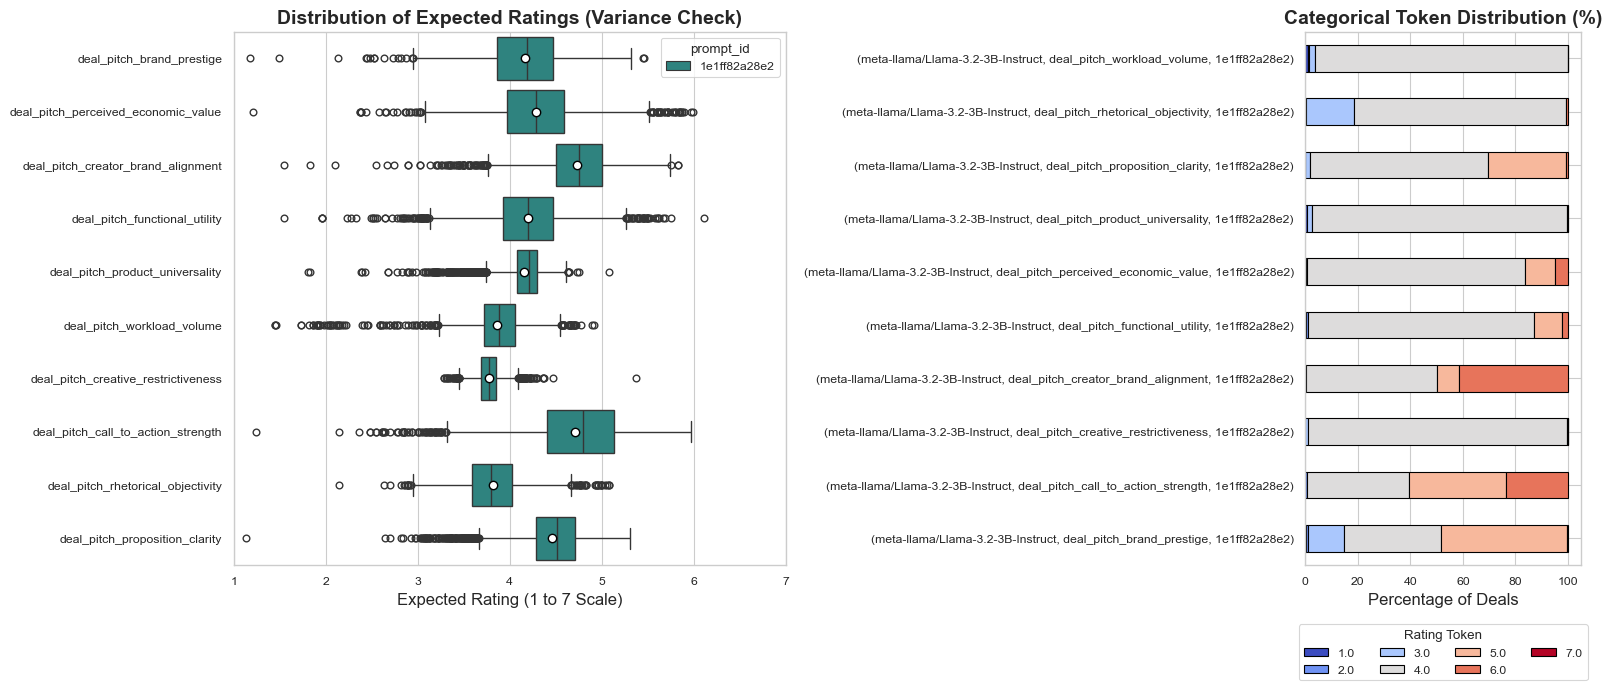

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import ast

# eda_df = final_df[final_df['model_name'] == 'Qwen/Qwen3.5-4B']
# eda_df = final_df[final_df['prompt_id'] == 'f162d59256cc']
prompts_to_analyse = ['f162d59256cc', '1e1ff82a28e2']
models_to_analyse = ['meta-llama/Llama-3.2-3B-Instruct']


eda_df = final_df[final_df['prompt_id'].isin(prompts_to_analyse)]
eda_df = eda_df[eda_df['model_name'].isin(models_to_analyse)]


def generate_llm_eda(df):
    """
    Generates EDA for LLM logit outputs, focusing on variance and entropy.
    """
    # 1. Clean the sorted_logits if they are stored as strings (common when reading from CSV)
    if isinstance(df['sorted_logits'].iloc[0], str):
        df['sorted_logits'] = df['sorted_logits'].apply(ast.literal_eval)

    # Flatten the nested lists if they are [[a, b, c, d]] -> [a, b, c, d]
    df['sorted_logits'] = df['sorted_logits'].apply(
        lambda x: x[0] if isinstance(x[0], list) else x)

    # 2. Descriptive Statistics Table
    group_cols = ['model_name', 'prompt_id', 'dimension_name']

    # We want to see if the model has variance (std) and how confident it is (entropy)
    descriptives = df.groupby(group_cols).agg(
        n_obs=('mode_rating', 'count'),

        # Mode Rating Descriptives
        mode_mean=('mode_rating', 'mean'),
        mode_std=('mode_rating', 'std'),

        # Mean Rating (Softmax) Descriptives
        expected_mean=('mean_rating', 'mean'),
        expected_std=('mean_rating', 'std'),

        # Entropy (Uncertainty)
        entropy_mean=('normalized_entropy', 'mean'),
        entropy_std=('normalized_entropy', 'std')
    ).reset_index()

    # Sort by standard deviation to easily spot zero-variance dimensions
    descriptives = descriptives.sort_values(by='expected_std', ascending=False)

    # Save the table for your thesis appendix
    # descriptives.to_csv("llm_psychometric_descriptives.csv", index=False)
    # print("✅ Descriptives saved to 'llm_psychometric_descriptives.csv'")
    print(descriptives[['prompt_id', 'dimension_name',
          'expected_std', 'entropy_mean']])

    # 3. Visualization: The Variance & Distribution Plot
    sns.set_theme(style="whitegrid", context="paper")

    # Create a figure with two subplots
    fig, axes = plt.subplots(1, 2, figsize=(
        16, 7), gridspec_kw={'width_ratios': [2, 1]})

    # Plot A: Boxplot of Mean Ratings to show variance per dimension
    sns.boxplot(
        data=df,
        y='dimension_name',
        x='mean_rating',
        hue='prompt_id',
        ax=axes[0],
        palette="viridis",
        showmeans=True,
        meanprops={"marker": "o", "markerfacecolor": "white",
                   "markeredgecolor": "black"}
    )
    axes[0].set_title(
        'Distribution of Expected Ratings (Variance Check)', fontsize=14, fontweight='bold')
    axes[0].set_xlabel('Expected Rating (1 to 7 Scale)', fontsize=12)
    axes[0].set_ylabel('')
    axes[0].set_xlim(1, 7)

    # Plot B: Stacked Bar Chart for the 1-4 Token Distribution (Mode)
    mode_counts = df.groupby(
        ['model_name', 'dimension_name', 'prompt_id', 'mode_rating']).size().unstack(fill_value=0)
    # Normalize to percentages
    mode_pct = mode_counts.div(mode_counts.sum(axis=1), axis=0) * 100

    mode_pct.plot(
        kind='barh',
        stacked=True,
        colormap='coolwarm',
        ax=axes[1],
        edgecolor='black'
    )
    axes[1].set_title('Categorical Token Distribution (%)',
                      fontsize=14, fontweight='bold')
    axes[1].set_xlabel('Percentage of Deals', fontsize=12)
    axes[1].set_ylabel('')
    axes[1].legend(title="Rating Token", loc='upper center',
                   bbox_to_anchor=(0.5, -0.1), ncol=4)

    plt.tight_layout()
    plt.savefig("llm_evaluation_distribution.png",
                dpi=300, bbox_inches='tight')
    plt.show()


# Run the function on your dataframe:
generate_llm_eda(eda_df)

In [ ]:
qwen_df = final_df[(final_df.model_name == 'Qwen/Qwen3.5-4B')
                   & (final_df.prompt_id == '1e1ff82a28e2')]

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

print("--- 🚀 VISUALIZING ARCHITECTURAL DIFFERENCES ---")

# 1. Merge for direct comparison
# (assuming you have input_id, dimension_name, mean_rating, mode_rating, and normalized_entropy in both dfs)
comp_df = pd.merge(
    qwen_dfa[['input_id', 'dimension_name', 'mean_rating',
             'mode_rating', 'normalized_entropy']],
    qwen_dfb[['input_id', 'dimension_name', 'mean_rating',
              'mode_rating', 'normalized_entropy']],
    on=['input_id', 'dimension_name'],
    suffixes=('_qwenNEW', '_qwenOLD')
)

# Set up the visual style
sns.set_theme(style="whitegrid")
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# ---------------------------------------------------------
# PLOT 1: Hexbin Density (Qwen vs Gemma Agreement)
# ---------------------------------------------------------
ax = axes[0, 0]
# Hexbin solves overplotting by showing the density of points
hb = ax.hexbin(comp_df['mean_rating_qwenNEW'], comp_df['mean_rating_qwenOLD'],
               gridsize=40, cmap='Blues', mincnt=1, bins='log')
# Line of perfect identity
ax.plot([1, 7], [1, 7], 'r--', lw=2, label='Perfect Agreement (y=x)')
ax.set_title("1. Expected Value Agreement: Qwen vs Gemma",
             fontsize=14, fontweight='bold')
ax.set_xlabel("Qwen NEW")
ax.set_ylabel("Qwen OLD(Discrete Bias)")
ax.legend(loc='upper left')
fig.colorbar(hb, ax=ax, label='Log10(Density)')

# ---------------------------------------------------------
# PLOT 2: KDE of Mean Ratings (The "Spikiness")
# ---------------------------------------------------------
ax = axes[0, 1]
# A lower bw_adjust prevents seaborn from over-smoothing the integer spikes
sns.kdeplot(comp_df['mean_rating_qwenNEW'], ax=ax, label='Qwen NEW',
            fill=True, color='blue', bw_adjust=0.4, alpha=0.4)
sns.kdeplot(comp_df['mean_rating_qwenOLD'], ax=ax, label='Qwen OLD',
            fill=True, color='orange', bw_adjust=0.4, alpha=0.4)
ax.set_title("2. Distribution of Ratings (Discretization Evidence)",
             fontsize=14, fontweight='bold')
ax.set_xlabel("Expected Value Rating (1 to 7)")
ax.set_ylabel("Density")
ax.legend()

# ---------------------------------------------------------
# PLOT 3: ECDF of Absolute Deviation (Mean minus Mode)
# ---------------------------------------------------------
ax = axes[1, 0]
comp_df['dev_qwenNEW'] = abs(
    comp_df['mean_rating_qwenNEW'] - comp_df['mode_rating_qwenNEW'])
comp_df['dev_qwenOLD'] = abs(
    comp_df['mean_rating_qwenOLD'] - comp_df['mode_rating_qwenOLD'])

sns.ecdfplot(comp_df['dev_qwenNEW'], ax=ax,
             label='Qwen NEW', color='blue', lw=2)
sns.ecdfplot(comp_df['dev_qwenOLD'], ax=ax,
             label='Qwen OLD', color='orange', lw=2)
ax.set_title("3. Cumulative Deviation from Integer Mode",
             fontsize=14, fontweight='bold')
ax.set_xlabel("Absolute Difference: |Mean Rating - Mode Rating|")
ax.set_ylabel("Cumulative Proportion of Evaluations")
# # Mark the medians you found earlier
# ax.axvline(0.14, color='orange', linestyle=':',
#            alpha=0.8, label='Qwen OLD Median (0.14)')
# ax.axvline(0.29, color='blue', linestyle=':',
#            alpha=0.8, label='Qwen NEW Median (0.29)')
# ax.legend()

# ---------------------------------------------------------
# PLOT 4: Entropy Distributions (The Root Cause)
# ---------------------------------------------------------
ax = axes[1, 1]
sns.kdeplot(comp_df['normalized_entropy_qwenNEW'], ax=ax,
            label='Qwen NEW', fill=True, color='blue', alpha=0.4)
sns.kdeplot(comp_df['normalized_entropy_qwenOLD'], ax=ax,
            label='Qwen OLD', fill=True, color='orange', alpha=0.4)
ax.set_title("4. Root Cause: Model Uncertainty (Entropy)",
             fontsize=14, fontweight='bold')
ax.set_xlabel(
    "Normalized Entropy (0 = Absolute Overconfidence, 1 = Max Uncertainty)")
ax.set_ylabel("Density")
ax.legend()

plt.tight_layout()
plt.show()

--- 🚀 VISUALIZING ARCHITECTURAL DIFFERENCES ---


NameError: name 'qwen_dfa' is not defined